**Cell 1 — Imports and configuration**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

OUTPUT_DIR = os.getcwd()

N = 100
SPAN = 5
ALPHA = 0.5   # |xi| used for Frechet/Weibull shape parameters

**Cell 2 — Build the x-grid**

In [2]:
xpos = SPAN * np.arange(1, N + 1) / N
xneg = -SPAN + xpos
x = np.concatenate([xneg, xpos])

**Cell 3 — Compute GEV densities for the three extreme value types**

In [ ]:
gumb_y = genextreme.pdf(x, c=0,       loc=0,  scale=1.0)  # Gumbel:  xi=0
frec_y = genextreme.pdf(x, c=-ALPHA,  loc=1,  scale=0.5)  # Frechet: xi=+0.5
weib_y = genextreme.pdf(x, c=ALPHA,   loc=-1, scale=0.5)  # Weibull: xi=-0.5

**Cell 4 — Plot, display and save**

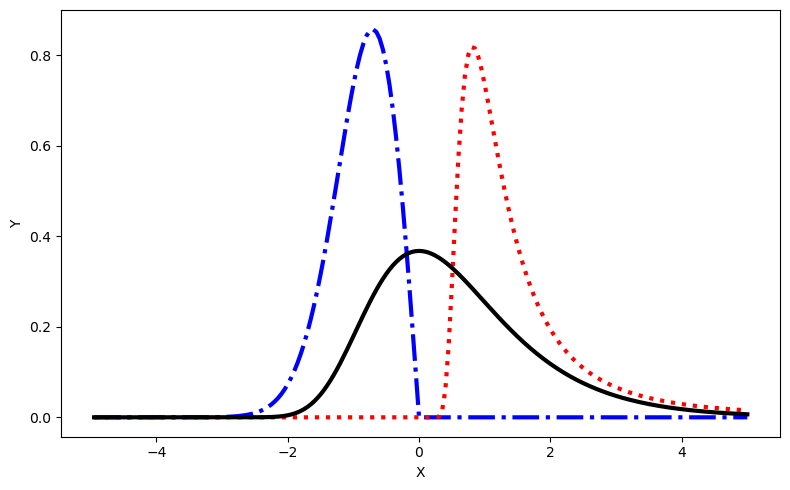

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, weib_y, color='blue',  linewidth=3, linestyle='dashdot', label='Weibull (ξ = −0.5)')
ax.plot(x, frec_y, color='red',   linewidth=3, linestyle='dotted',  label='Fréchet (ξ = +0.5)')
ax.plot(x, gumb_y, color='black', linewidth=3, linestyle='solid',   label='Gumbel (ξ = 0)')

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "extreme_value_densities.png"),
            dpi=200, transparent=True, bbox_inches='tight')
plt.show()